In [ ]:
from google.colab import files
uploaded=files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import pandas as pd
df=pd.read_csv('Mall_Customers.csv')
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [ ]:
display(df.describe())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.440000,38.850000,60.560000,50.200000,1.400000
std,57.879185,0.497633,13.969007,26.264721,25.823522,1.449311
min,1.000000,0.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,0.000000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,0.000000,36.000000,61.500000,50.000000,1.000000
75%,150.250000,1.000000,49.000000,78.000000,73.000000,3.000000
max,200.000000,1.000000,70.000000,137.000000,99.000000,4.000000


In [ ]:
display(df.isnull().sum())

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Cluster,0


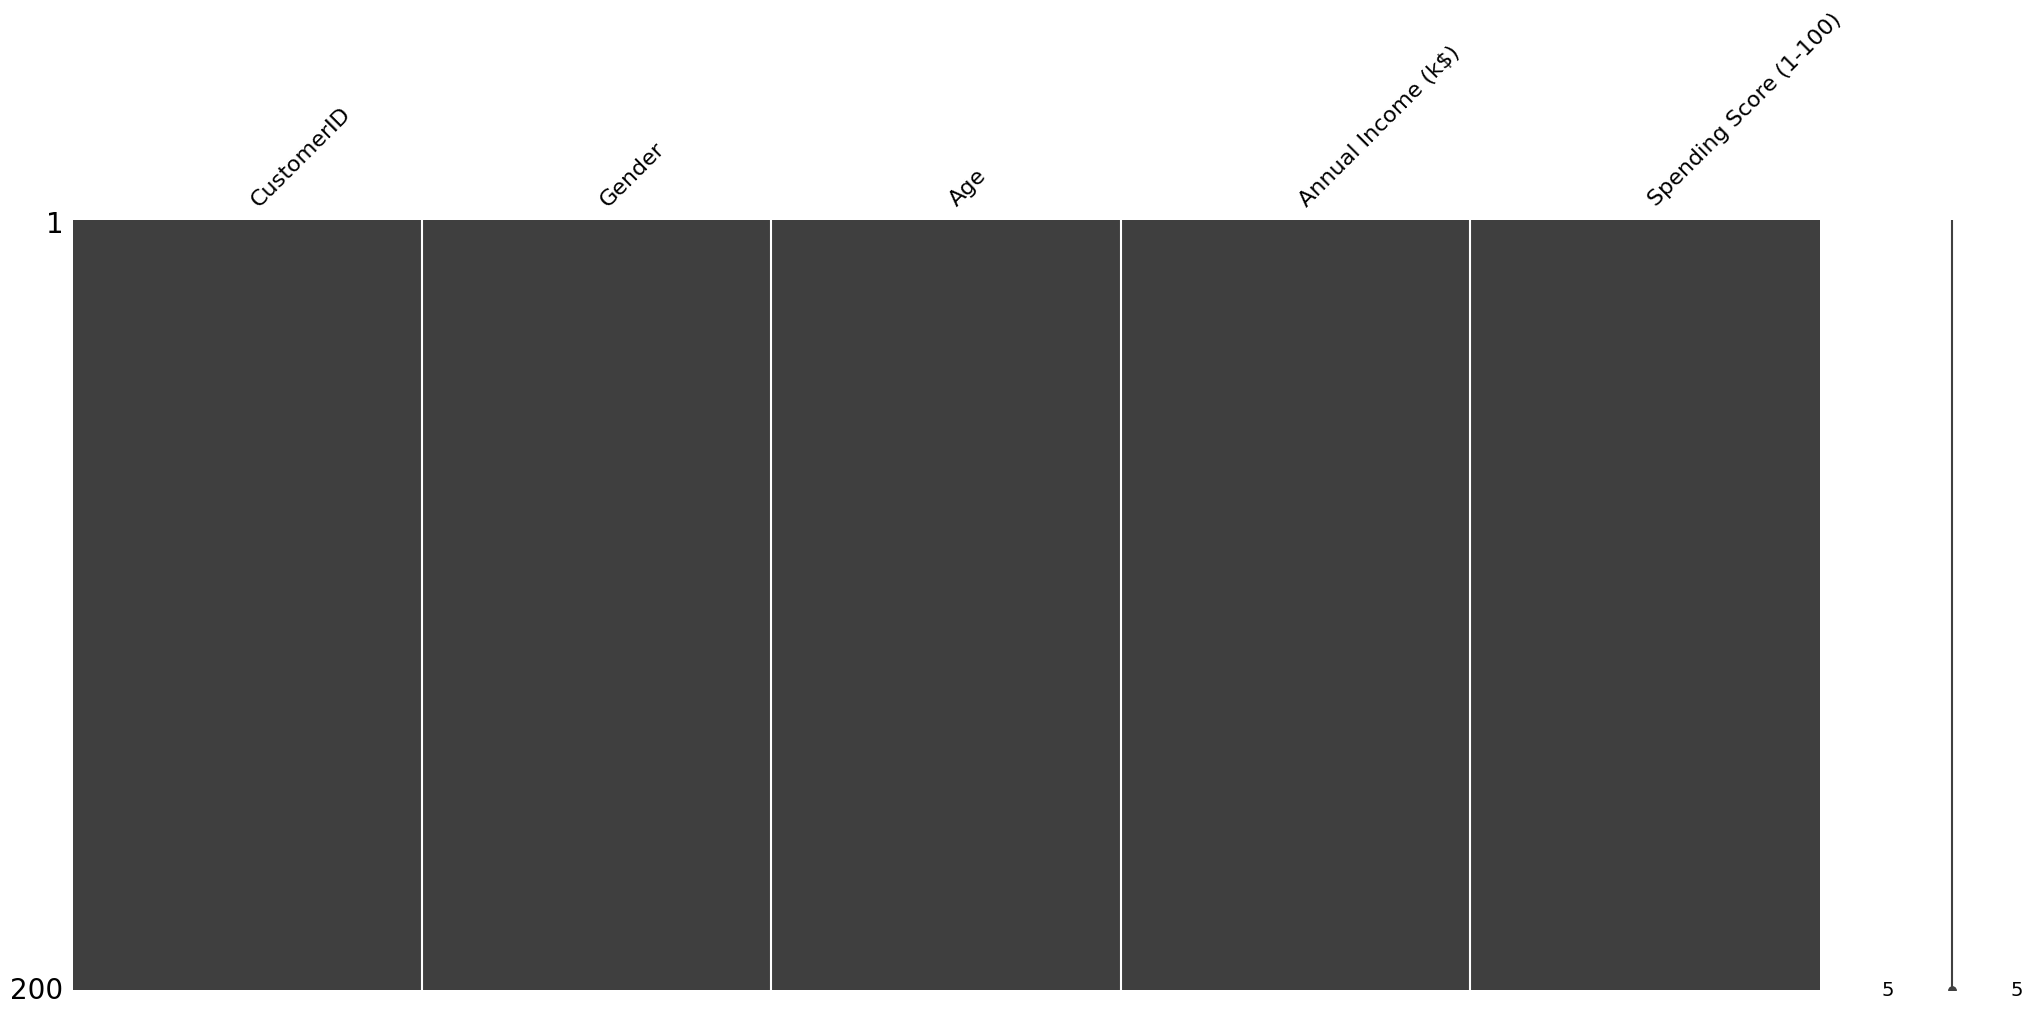

In [ ]:
import matplotlib.pyplot as plt
import missingno as msno
msno.matrix(df)
plt.show()

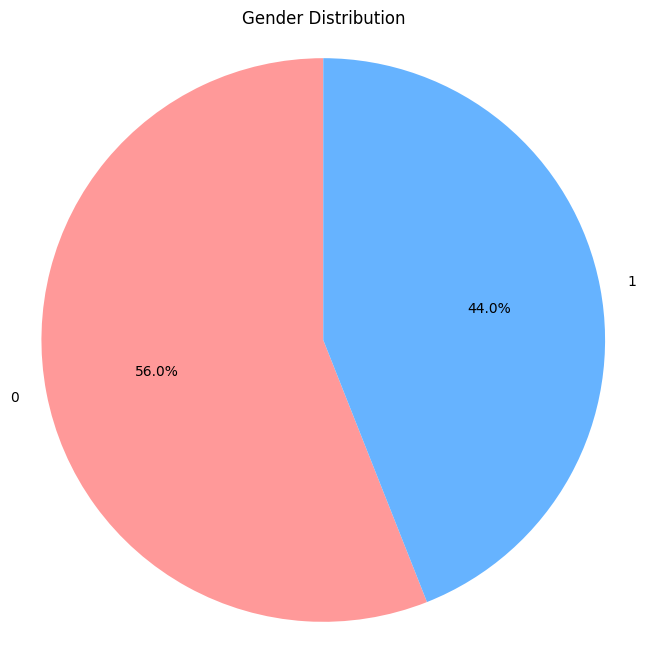

In [ ]:
gender_counts = df['Gender'].value_counts()

fig = plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Gender Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
import plotly.express as px
fig = px.pie(
    df,
    names='Gender',
    title='Gender Distribution of customers',
    hole=0.4,
    width=800,
    height=600
)
fig.show()

In [ ]:
fig=px.histogram(
    df,x='Age',
    nbins=15,title='Age Distribution of Customers',
    marginal='box',
    width=800,
    height=600
)
fig.show()

In [ ]:
fig=px.histogram(
    df,x='Annual Income (k$)',
    nbins=15,title='Annual income of Customers',
    marginal='box',
    width=800,
    height=600
)
fig.show()

In [ ]:
fig = px.scatter(
    df,
    x='Age',
    y='Spending Score (1-100)',
    color='Gender',
    title='Age vs. Spending Score',
    width=800,
    height=600
)
fig.show()

In [ ]:
fig = px.scatter(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='Gender',
    title='Annual Income vs. Spending Score',
    width=800,
    height=600
)
fig.update_traces(marker=dict(size=10))
fig.show()

In [ ]:
df["Gender"] = df["Gender"].map({'Male':1,'Female':0})


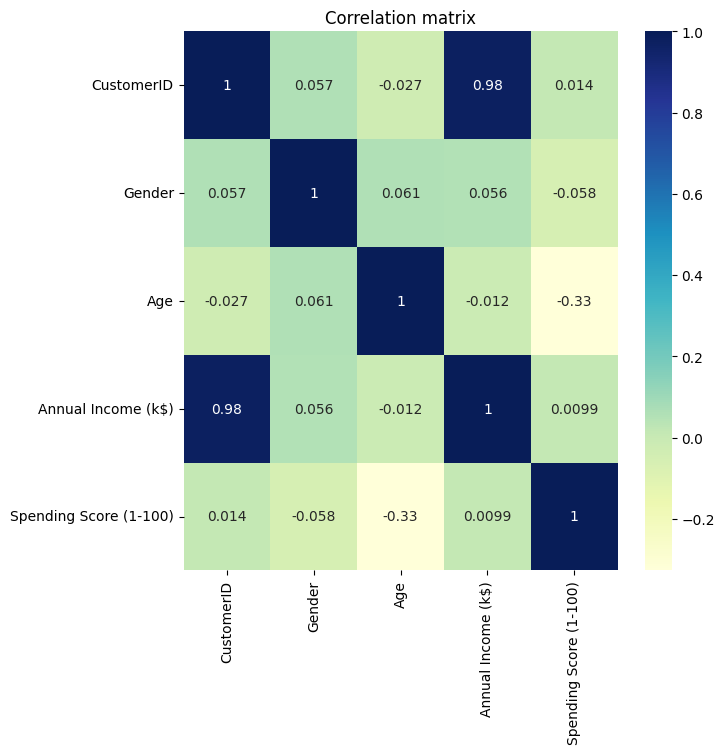

In [ ]:
corr=df.corr()
plt.figure(figsize=(7,7))
sns.heatmap(corr,annot=True,cmap='YlGnBu')
plt.title("Correlation matrix")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"]=kmeans.fit_predict(
    df[["Annual Income (k$)", "Spending Score (1-100)"]]
)


In [ ]:
fig = px.scatter(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='Cluster',
    title='Customer Segments by Annual Income and Spending Score',
    hover_data=['Gender', 'Age'],
    width=900,
    height=700
)
fig.update_layout(showlegend=True)
fig.show()

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


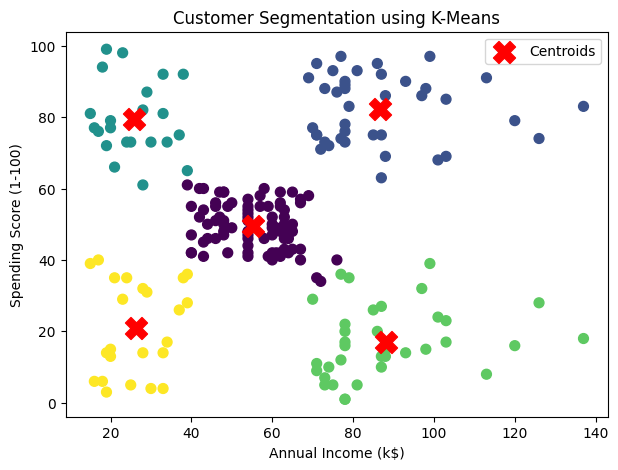

In [ ]:
# Visualize clusters
plt.figure(figsize=(7,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=250,
    color='red',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Gender',   # Optional
    title='3D Customer Distribution',
    width=900,
    height=700
)

fig.show()